In [1]:
#Import a function from another notebook:
# !pip install import-ipynb
import import_ipynb
from Crop_Interpolate_Grid_Save_In_New_file import newlonlat_city

#Other imports:
import xarray as xr
import xesmf as xe
import numpy as np
import matplotlib.pyplot as plt

{'gridtype': 'lonlat', 'xsize': 89, 'ysize': 59, 'xfirst': 0.828125, 'xinc': 0.03125, 'yfirst': 47.921875, 'yinc': 0.03125}
(89,) (59,)


FileNotFoundError: [Errno 2] No such file or directory: '/nfs/home/gmeteo/moralesi/Repositorios/I4C_IreneMorales/ta1000_ALPX-3f_ERA5_evaluation_r1i1p1f1_BCCR-UCAN_WRF451R-CI4C_v1-r1_6hr_202301010000-202312311800.nc'

In [1]:
## Variables:

#Data path and file name:
path='C:/Users/irene/PracticasUC/'
path_save='C:/Users/irene/PracticasUC/cropped_files/'
file= 'ta1000_ALPX-3f_ERA5_evaluation_r1i1p1f1_BCCR-UCAN_WRF451R-CI4C_v1-r1_6hr_202301010000-202312311800.nc'
variable, domain, reanalisis, simulation_tipe, run_type1, runing_centre, model, run_type2, time_interval, time_period = file.split("_")
# print(variable, domain, reanalisis, simulation_tipe, run_type1, runing_centre, model, run_type2, time_interval, time_period)

#City name
city_name='Paris'

# List of interpolation methods to compare
method_list = [
    "bilinear",
    "nearest_s2d",
    "nearest_d2s",
    "patch",
]

# Get the target grid coordinates and grid parameters
lon_target, lat_target, x_first, xend, x_size, y_size, xinc, yinc, y_first, yend = newlonlat_city(city_name)

# Create 2D longitude and latitude arrays from the 1D coordinates
lon2d_target, lat2d_target = np.meshgrid(lon_target, lat_target)

# Create the target grid dataset
ds_out = xr.Dataset(
    {
        "lon": (("y", "x"), lon2d_target),
        "lat": (("y", "x"), lat2d_target),
    },
    coords={
        "x": lon_target,
        "y": lat_target,
    }
)

# Read the input dataset
ds = xr.open_dataset(path + file)

# Crop the dataset to the city domain
city = ds.where(
    (ds.lon >= x_first) & (ds.lon <= xend) &
    (ds.lat >= y_first) & (ds.lat <= yend),
    drop=True
)

# Create the source grid dataset using the original coordinates
ds_in = xr.Dataset(
    {
        "lon": city["lon"],
        "lat": city["lat"],
    }
)

# Create an empty dataset to store the interpolated fields
ds_city_interp = xr.Dataset(
    coords={
        "x": lon_target,
        "y": lat_target,
        "lon": (("y", "x"), lon2d_target),
        "lat": (("y", "x"), lat2d_target),
    }
)

# Interpolate the variable using each method
for method in method_list:
    print(f"Interpolating with method: {method}")

    regridder = xe.Regridder(
        ds_in,
        ds_out,
        method=method,
        periodic=False,
        ignore_degenerate=True
    )

    ds_city_interp[method] = regridder(city[var])

# Compute the difference between each method and bilinear interpolation
for method in method_list:
    if method != "bilinear":
        ds_city_interp[f"{method}_minus_bilinear"] = (
            ds_city_interp[method] - ds_city_interp["bilinear"]
        )

# # Plot the interpolated fields
# for method in method_list:
#     plt.figure(figsize=(6, 5))

#     ds_city_interp[method].isel(time=0).plot.pcolormesh(
#         x="x",
#         y="y",
#         cmap="viridis"
#     )

#     plt.title(method)
#     plt.show()

 

    data_plot = ds_city_interp[method].isel(time=0)

    # Keep only physically meaningful values between 270 and 290 K
    data_plot = data_plot.where((data_plot >= 270) & (data_plot <= 290))

    data_plot.plot.pcolormesh(
        x="x",
        y="y",
        cmap="viridis"
    )

    plt.title(method)
    plt.show()

# Plot the differences relative to bilinear interpolation
for method in method_list:
    if method != "bilinear":
        plt.figure(figsize=(6, 5))

        ds_city_interp[f"{method}_minus_bilinear"].isel(time=0).plot.pcolormesh(
            x="x",
            y="y",
            cmap="RdBu_r"
        )

        plt.title(f"{method} - bilinear")
        plt.show()

NameError: name 'newlonlat_city' is not defined

{'gridtype': 'lonlat', 'xsize': 89, 'ysize': 59, 'xfirst': 0.828125, 'xinc': 0.03125, 'yfirst': 47.921875, 'yinc': 0.03125}
(89,) (59,)
Interpolating with method: bilinear
Interpolating with method: conservative
Interpolating with method: conservative_normed
Interpolating with method: nearest_s2d
Interpolating with method: nearest_d2s
Interpolating with method: patch


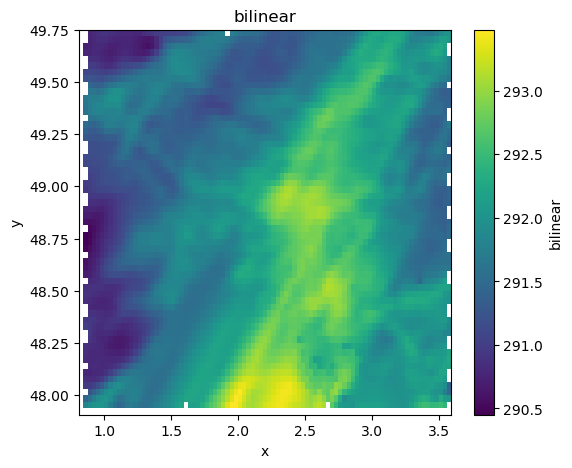

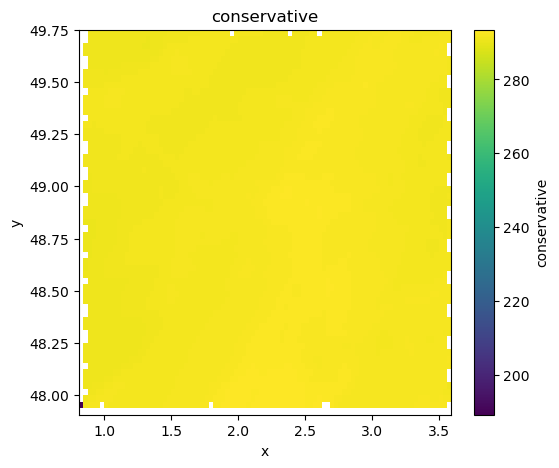

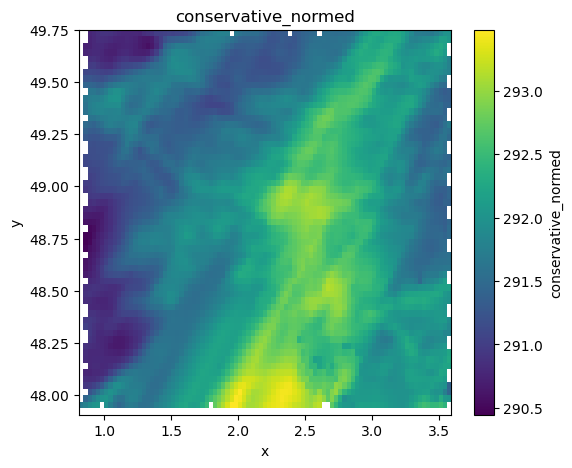

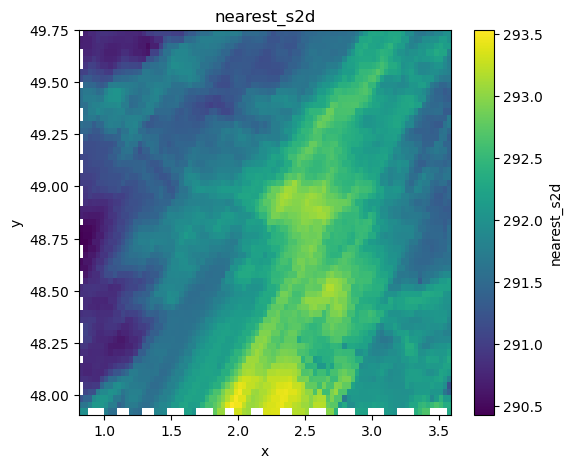

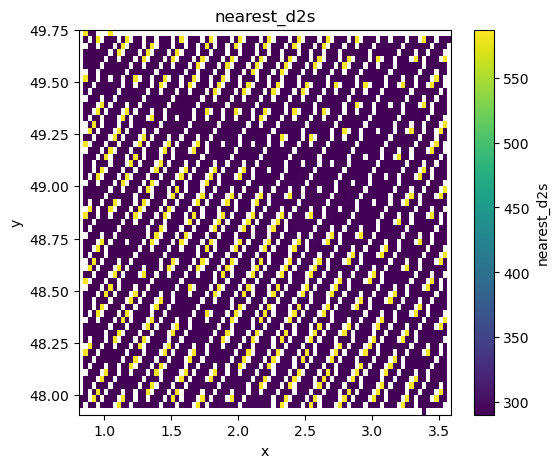

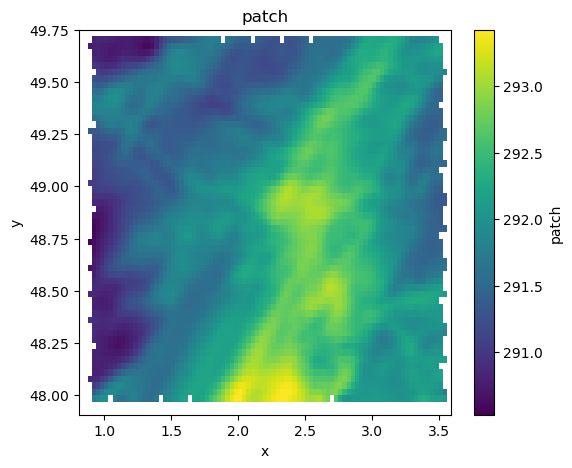

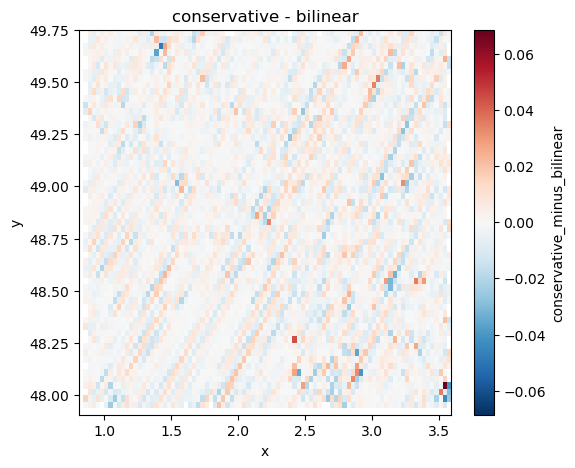

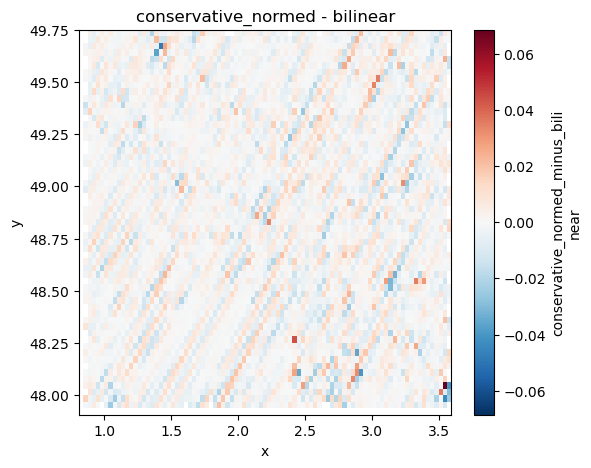

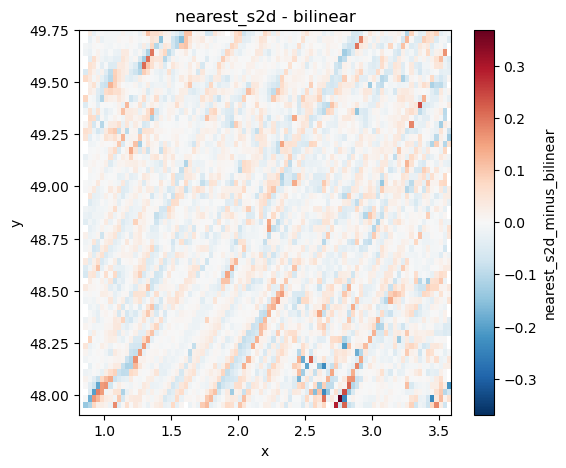

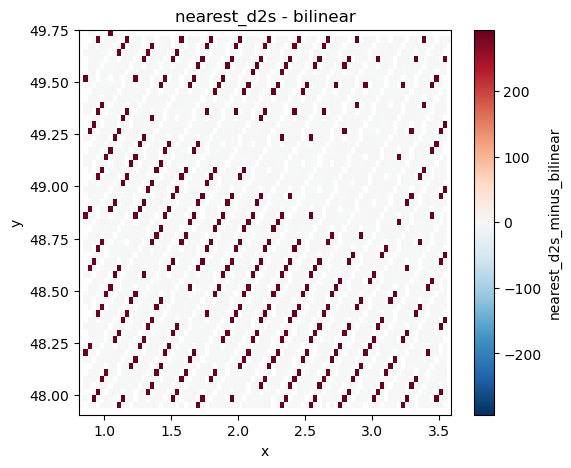

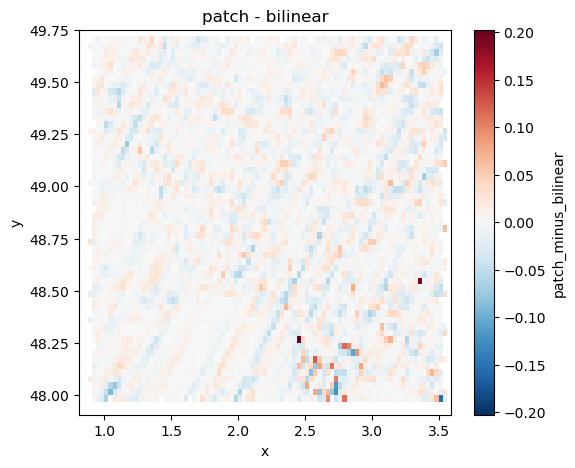

In [4]:
## Variables:

#Data path and file name:
path='C:/Users/irene/PracticasUC/'
path_save='C:/Users/irene/PracticasUC/cropped_files/'
file= 'ta1000_ALPX-3f_ERA5_evaluation_r1i1p1f1_BCCR-UCAN_WRF451R-CI4C_v1-r1_6hr_202301010000-202312311800.nc'
variable, domain, reanalisis, simulation_tipe, run_type1, runing_centre, model, run_type2, time_interval, time_period = file.split("_")
# print(variable, domain, reanalisis, simulation_tipe, run_type1, runing_centre, model, run_type2, time_interval, time_period)

#City name
city_name='Paris'

method_list = [
    "bilinear",
    "conservative",
    "conservative_normed",
    "nearest_s2d",
    "nearest_d2s",
    "patch",
]

def centers_to_bounds_1d(coord):
    """Create 1D cell bounds from 1D cell centers."""
    coord = np.asarray(coord)

    mid = 0.5 * (coord[1:] + coord[:-1])

    first = coord[0] - 0.5 * (coord[1] - coord[0])
    last = coord[-1] + 0.5 * (coord[-1] - coord[-2])

    bounds = np.concatenate([[first], mid, [last]])

    return bounds


def centers_to_bounds_2d(lon, lat):
    """Approximate 2D cell bounds from 2D cell centers."""
    lon = np.asarray(lon)
    lat = np.asarray(lat)

    ny, nx = lon.shape

    lon_b = np.empty((ny + 1, nx + 1))
    lat_b = np.empty((ny + 1, nx + 1))

    lon_b[1:-1, 1:-1] = 0.25 * (
        lon[:-1, :-1] + lon[1:, :-1] + lon[:-1, 1:] + lon[1:, 1:]
    )

    lat_b[1:-1, 1:-1] = 0.25 * (
        lat[:-1, :-1] + lat[1:, :-1] + lat[:-1, 1:] + lat[1:, 1:]
    )

    lon_b[0, 1:-1] = lon_b[1, 1:-1] - (lon_b[2, 1:-1] - lon_b[1, 1:-1])
    lon_b[-1, 1:-1] = lon_b[-2, 1:-1] + (lon_b[-2, 1:-1] - lon_b[-3, 1:-1])
    lon_b[1:-1, 0] = lon_b[1:-1, 1] - (lon_b[1:-1, 2] - lon_b[1:-1, 1])
    lon_b[1:-1, -1] = lon_b[1:-1, -2] + (lon_b[1:-1, -2] - lon_b[1:-1, -3])

    lat_b[0, 1:-1] = lat_b[1, 1:-1] - (lat_b[2, 1:-1] - lat_b[1, 1:-1])
    lat_b[-1, 1:-1] = lat_b[-2, 1:-1] + (lat_b[-2, 1:-1] - lat_b[-3, 1:-1])
    lat_b[1:-1, 0] = lat_b[1:-1, 1] - (lat_b[1:-1, 2] - lat_b[1:-1, 1])
    lat_b[1:-1, -1] = lat_b[1:-1, -2] + (lat_b[1:-1, -2] - lat_b[1:-1, -3])

    lon_b[0, 0] = lon_b[0, 1] + lon_b[1, 0] - lon_b[1, 1]
    lon_b[0, -1] = lon_b[0, -2] + lon_b[1, -1] - lon_b[1, -2]
    lon_b[-1, 0] = lon_b[-2, 0] + lon_b[-1, 1] - lon_b[-2, 1]
    lon_b[-1, -1] = lon_b[-2, -1] + lon_b[-1, -2] - lon_b[-2, -2]

    lat_b[0, 0] = lat_b[0, 1] + lat_b[1, 0] - lat_b[1, 1]
    lat_b[0, -1] = lat_b[0, -2] + lat_b[1, -1] - lat_b[1, -2]
    lat_b[-1, 0] = lat_b[-2, 0] + lat_b[-1, 1] - lat_b[-2, 1]
    lat_b[-1, -1] = lat_b[-2, -1] + lat_b[-1, -2] - lat_b[-2, -2]

    return lon_b, lat_b


lon_target, lat_target, x_first, xend, x_size, y_size, xinc, yinc, y_first, yend = newlonlat_city(city_name)

lon2d_target, lat2d_target = np.meshgrid(lon_target, lat_target)

lon_b_target_1d = centers_to_bounds_1d(lon_target)
lat_b_target_1d = centers_to_bounds_1d(lat_target)

lon2d_b_target, lat2d_b_target = np.meshgrid(lon_b_target_1d, lat_b_target_1d)

ds_out = xr.Dataset(
    {
        "lon": (("y", "x"), lon2d_target),
        "lat": (("y", "x"), lat2d_target),
        "lon_b": (("y_b", "x_b"), lon2d_b_target),
        "lat_b": (("y_b", "x_b"), lat2d_b_target),
    },
    coords={
        "x": lon_target,
        "y": lat_target,
        "x_b": lon_b_target_1d,
        "y_b": lat_b_target_1d,
    }
)

ds = xr.open_dataset(path + file)

city = ds.where(
    (ds.lon >= x_first) & (ds.lon <= xend) &
    (ds.lat >= y_first) & (ds.lat <= yend),
    drop=True
)

lon_b_source, lat_b_source = centers_to_bounds_2d(
    city["lon"].values,
    city["lat"].values
)

ds_in = xr.Dataset(
    {
        "lon": city["lon"],
        "lat": city["lat"],
        "lon_b": (("y_b", "x_b"), lon_b_source),
        "lat_b": (("y_b", "x_b"), lat_b_source),
    }
)

ds_city_interp = xr.Dataset(
    coords={
        "x": lon_target,
        "y": lat_target,
        "lon": (("y", "x"), lon2d_target),
        "lat": (("y", "x"), lat2d_target),
    }
)

successful_methods = []

for method in method_list:
    print(f"Interpolating with method: {method}")

    try:
        regridder = xe.Regridder(
            ds_in,
            ds_out,
            method=method,
            periodic=False,
            ignore_degenerate=True,
            unmapped_to_nan=True
        )

        ds_city_interp[method] = regridder(city[variable])
        successful_methods.append(method)

    except Exception as error:
        print(f"Method {method} failed and was skipped.")
        print(error)

for method in successful_methods:
    if method != "bilinear" and "bilinear" in successful_methods:
        ds_city_interp[f"{method}_minus_bilinear"] = (
            ds_city_interp[method] - ds_city_interp["bilinear"]
        )

for method in successful_methods:
    plt.figure(figsize=(6, 5))

    ds_city_interp[method].isel(time=0).plot.pcolormesh(
        x="x",
        y="y",
        cmap="viridis"
    )

    plt.title(method)
    plt.show()

for method in successful_methods:
    if method != "bilinear" and "bilinear" in successful_methods:
        plt.figure(figsize=(6, 5))

        ds_city_interp[f"{method}_minus_bilinear"].isel(time=0).plot.pcolormesh(
            x="x",
            y="y",
            cmap="RdBu_r"
        )

        plt.title(f"{method} - bilinear")
        plt.show()